# 05 — Where to put the parallelism

The bipartite update is mandatory and is on in **every** row. This notebook is
not about whether the algorithm is correct; it is about how to spend parallel
hardware once correctness is settled.

**Fixed configuration throughout:** 4 states x 100 replicas = **400 independent
chains**, annealed over **200 temperature points x (10,000 + 5,000) sweeps**.
All four groupings move that same total work; only the arrangement changes.

| mode | grouping | the axis it uses |
|---|---|---|
| **BP only** | 400 launches of 1 chain | the bipartite update alone |
| **BP + replicas** | 4 launches of 100 chains | batch over seeds, one state at a time |
| **BP + states** | 100 launches of 4 chains | batch over states, one seed at a time |
| **BP + replicas + states** | 1 launch of 400 chains | both axes at once |

The four states are the medians of four phase clusters in the released dataset —
`uniform`, `helical`, `points` (skyrmions) and `lines` (labyrinth) — so they are
configurations that exist rather than invented corners. All carry
`Jex2 = Jex3 = Jex4 = 0`, which makes the bipartite colouring exact for each.

**Six of the sixteen cells are measured end to end**: the two groupings that
actually scale, on 1, 2 and 4 H100. The other ten are extrapolated from a
measured per-sweep rate, and are marked as such everywhere they appear.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

ANCHOR = "axes400_1gpu.json"
def find_results():
    for p in (pathlib.Path("results"),
              pathlib.Path("notebooks/simulation/results"),
              pathlib.Path("/kaggle/input/nanodisk-timing-results")):
        if (p / ANCHOR).exists():
            return p
    root = pathlib.Path("/kaggle/input")
    if root.exists():
        hit = next(root.glob(f"**/{ANCHOR}"), None)
        if hit:
            return hit.parent
        raise FileNotFoundError(
            f"{ANCHOR} not found. Mounted: {[p.name for p in root.iterdir()]}")
    raise FileNotFoundError(ANCHOR)

RES = find_results(); print("reading from", RES)
load = lambda n: json.load(open(RES / f"{n}.json"))

LADDER = 200 * 15000
CFG  = [("bp_only", "BP only"), ("replicas", "BP + replicas"),
        ("states", "BP + states"), ("both", "BP + replicas + states")]
ARMS = [(0, "CPU"), (1, "1x H100"), (2, "2x H100"), (4, "4x H100")]

RATE = {g: load("axes400_cpu" if g == 0 else f"axes400_{g}gpu") for g, _ in ARMS}
# Full ladders, measured end to end, for the two groupings worth running.
FULL = {}
for cfg in ("replicas", "both"):
    for g in (1, 2, 4):
        try:
            d = load(f"axl_{cfg}_{g}gpu")
            assert d["measured_full_ladder"] and d["total_chains"] == 400
            assert d["n_temps"] == 200 and d["n_therm"] == 10000
            FULL[(g, cfg)] = d["elapsed_s"] / 3600
        except FileNotFoundError:
            pass

def hours(g, c):
    """Measured ladder if one exists, else the rate times the ladder length."""
    if (g, c) in FULL:
        return FULL[(g, c)], True
    r = next(x for x in RATE[g]["rows"] if x["config"] == c)
    return r["ms_per_sweep"] * LADDER / 3.6e6, False

def ht(h):
    if h > 48: return f"{h/24:,.1f} d"
    if h < 1:  return f"{h*60:.1f} min"
    return f"{h:,.1f} h"

print(f"{len(FULL)} cells measured end to end, "
      f"{16-len(FULL)} extrapolated from a measured rate")
for t in RATE[1]["thetas"]:
    print(f"   {t['name']:9s} Kan1={t['Kan1']:.3f}  Hex={t['Hex']:.3f}  "
          f"KDM={t['KDM']:.3f}")

reading from results
6 cells measured end to end, 10 extrapolated from a measured rate
   uniform   Kan1=0.287  Hex=0.769  KDM=0.654
   helical   Kan1=0.259  Hex=0.093  KDM=1.025
   points    Kan1=0.278  Hex=0.389  KDM=1.000
   lines     Kan1=0.508  Hex=0.022  KDM=0.512


## The table

In [2]:
hdr = (f"{'mode':24s}{'device':>9}{'TOTAL':>12}{'per state':>12}"
       f"{'source':>14}{'vs best':>9}")
for g, dev in ARMS:
    print(f"\n{'='*len(hdr)}\n{dev}\n{'='*len(hdr)}")
    print(hdr); print("-" * len(hdr))
    vals = {c: hours(g, c)[0] for c, _ in CFG}
    best = min(vals.values())
    for c, name in CFG:
        h, meas = hours(g, c)
        print(f"{name:24s}{dev:>9}{ht(h):>12}{ht(h/4):>12}"
              f"{'MEASURED' if meas else 'extrapolated':>14}{h/best:8.2f}x")

print(f"\n\n{'mode':24s}{'1->2':>8}{'1->4':>8}{'ideal':>8}")
print("-" * 48)
for c, name in CFG:
    v = {g: hours(g, c)[0] for g in (1, 2, 4)}
    print(f"{name:24s}{v[1]/v[2]:7.2f}x{v[1]/v[4]:7.2f}x{'4.00x':>8}")


CPU
mode                       device       TOTAL   per state        source  vs best
--------------------------------------------------------------------------------
BP only                       CPU      79.4 d      19.8 d  extrapolated   10.48x
BP + replicas                 CPU      10.3 d       2.6 d  extrapolated    1.35x
BP + states                   CPU      45.4 d      11.4 d  extrapolated    6.00x
BP + replicas + states        CPU       7.6 d      45.5 h  extrapolated    1.00x

1x H100
mode                       device       TOTAL   per state        source  vs best
--------------------------------------------------------------------------------
BP only                   1x H100       5.8 h       1.4 h  extrapolated    6.67x
BP + replicas             1x H100    51.7 min    12.9 min      MEASURED    1.00x
BP + states               1x H100       1.8 h    26.8 min  extrapolated    2.07x
BP + replicas + states    1x H100       1.0 h    15.5 min      MEASURED    1.20x

2x H100
mode 

## A claim this notebook previously made, and retracts

An earlier version of this notebook reported that `BP + replicas` **beat**
`BP + replicas + states` on 2 and 4 GPUs, by 18.6% and 13.8%, and called the
difference real at **154 and 301 sigma** on the strength of three repeats inside
one container.

**Measuring the full ladders overturns it.**

| | 1x H100 | 2x H100 | 4x H100 |
|---|---|---|---|
| extrapolated gap (replicas − both) | +13% | **−19%** | **−14%** |
| **measured gap** | +17% | −8% | **+3%** |

On four GPUs `BP + replicas + states` is now the faster of the two (16.4 against
16.9 min) — the opposite of what was published. On two GPUs the gap survives but
is less than half its reported size. And the superlinear `4.69x` scaling that
prompted a cache-residency hypothesis does not exist: measured, it is 3.06x.

**The sigma figure was not wrong, it was measuring the wrong thing.** Three
repeats of the same 2,000-sweep loop in one container agree to 0.0001 ms/sweep,
so the *rate* was pinned precisely. But that loop is the bare spin update, while
a production ladder also computes every observable on every measurement sweep —
a different workload whose overhead is not a constant factor across groupings. A
tight error bar on the wrong quantity reads exactly like a result.

**The standing lesson:** per-sweep rates extrapolate well enough to separate
orders of magnitude — CPU against GPU, 79 days against 15 minutes — and not well
enough to rank two configurations that differ by 10–20%. For that, measure the
thing itself. Errors here ran from −23% to +19%.

### How far off, cell by cell

The retraction above rests on these six numbers.

Two effects pull in opposite directions, which is why the errors do not share a
sign and no correction factor could have rescued the extrapolation:

1. **Missing observables** push the extrapolation *low*. The rate study timed the
   bare spin update; a production ladder also computes every observable on every
   measurement sweep. Measured separately, that overhead is +8.2%, +15.3% and
   +19.1% on 1, 2 and 4 GPUs.
2. **Fixed per-launch cost** pushes it *high*. The rate study ran batches of
   2,000 sweeps; a real ladder runs 750,000 per launch, which dilutes that fixed
   cost to nothing.

`replicas 1x H100` is where the second effect wins outright — four launches of
only 2,000 sweeps each — and it is the one cell whose extrapolation came out
**high**, by 19%. Everywhere else the observables dominate and the estimate is
low.

In [3]:
# How far the extrapolations were off, cell by cell. This is the quantitative
# basis for the retraction above: the errors are the same size as the
# differences that were being reported as findings.
ovh = {g: load(f"overhead_{g}gpu")["overhead_pct"] for g in (1, 2, 4)}
rows = []
print(f"{'cell':24s}{'extrapolated':>14}{'MEASURED':>12}{'error':>9}{'ratio':>8}")
print("-" * 67)
for cfg in ("replicas", "both"):
    for g in (1, 2, 4):
        e = next(r for r in RATE[g]["rows"]
                 if r["config"] == cfg)["ms_per_sweep"] * LADDER / 3.6e6 * 60
        m = FULL[(g, cfg)] * 60
        err = 100 * (e - m) / m
        rows.append((cfg, g, e, m, err))
        print(f"{cfg + '  ' + str(g) + 'x H100':24s}{e:11.1f} min{m:9.1f} min"
              f"{err:8.1f}%{e/m:8.2f}x")

err = np.array([r[4] for r in rows])
print(f"\nmean error        {err.mean():+6.1f}%")
print(f"mean |error|      {np.abs(err).mean():6.1f}%")
print(f"range             {err.min():+.1f}% .. {err.max():+.1f}%")

print("\n\nTwo effects pull in opposite directions, which is why no single")
print("correction factor exists.\n")
print(f"{'cell':24s}{'from observables':>18}{'observed':>11}{'residual':>11}")
print("-" * 64)
for cfg, g, e, m, obs in rows:
    # Missing observables alone would make the extrapolation low by this much.
    pred = -ovh[g] / (1 + ovh[g] / 100)
    print(f"{cfg + '  ' + str(g) + 'x':24s}{pred:17.1f}%{obs:10.1f}%{obs-pred:10.1f}%")

cell                      extrapolated    MEASURED    error   ratio
-------------------------------------------------------------------
replicas  1x H100              61.4 min     51.7 min    18.7%    1.19x
replicas  2x H100              22.1 min     27.6 min   -19.9%    0.80x
replicas  4x H100              13.1 min     16.9 min   -22.5%    0.77x
both  1x H100                  54.1 min     62.1 min   -13.0%    0.87x
both  2x H100                  27.1 min     30.1 min    -9.9%    0.90x
both  4x H100                  15.2 min     16.4 min    -7.3%    0.93x

mean error          -9.0%
mean |error|        15.2%
range             -22.5% .. +18.7%


Two effects pull in opposite directions, which is why no single
correction factor exists.

cell                      from observables   observed   residual
----------------------------------------------------------------
replicas  1x                         -7.6%      18.7%      26.3%
replicas  2x                        -13.2%     -19.9%      -6.

## The charts

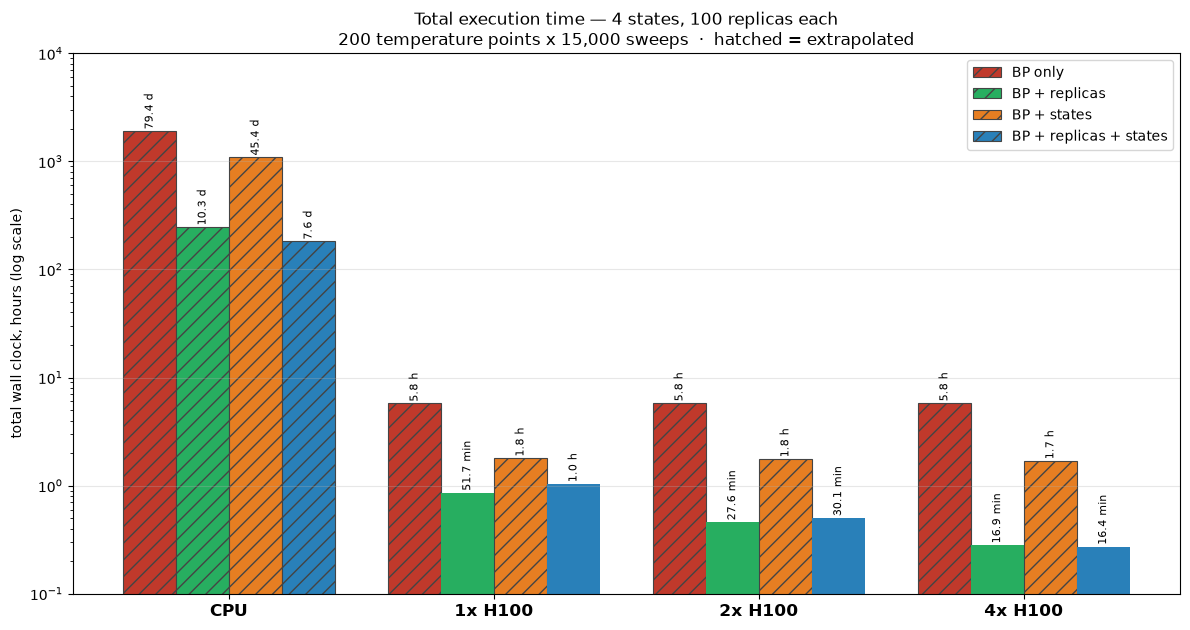

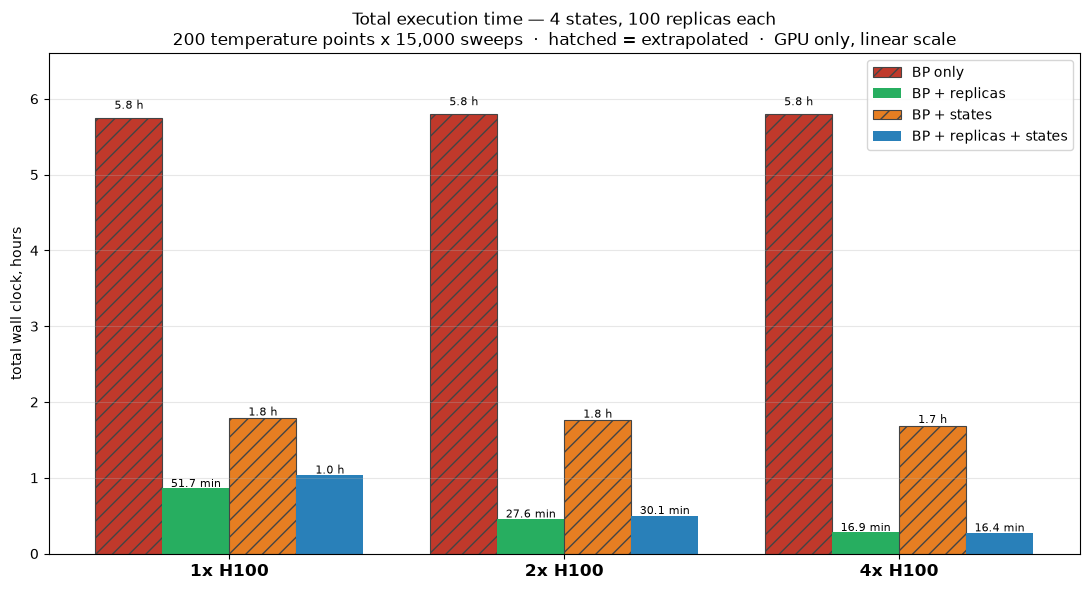

In [4]:
CMODE = {"bp_only": "#c0392b", "replicas": "#27ae60",
         "states": "#e67e22", "both": "#2980b9"}
NAME = dict(CFG)

def draw(arms, logscale, title, figsize, ylim=None):
    fig, ax = plt.subplots(figsize=figsize)
    w, x = 0.2, np.arange(len(arms))
    for i, (c, _) in enumerate(CFG):
        hs = [hours(g, c) for g, _ in arms]
        v = [h for h, _ in hs]
        # Hatched where the bar is an extrapolation rather than a measurement.
        for j, ((h, meas), xi) in enumerate(zip(hs, x)):
            ax.bar(xi + (i - 1.5) * w, h, w, color=CMODE[c],
                   hatch=None if meas else "//",
                   edgecolor="none" if meas else "#444",
                   linewidth=0 if meas else 0.8,
                   label=NAME[c] if j == 0 else None)
            ax.text(xi + (i - 1.5) * w, h * 1.1 if logscale else h + max(v)*0.02,
                    ht(h), ha="center", fontsize=8,
                    rotation=90 if logscale else 0)
    ax.set_xticks(x); ax.set_xticklabels([d for _, d in arms], fontsize=12,
                                         weight="bold")
    if logscale:
        ax.set_yscale("log"); ax.set_ylim(0.1, 1e4)
    else:
        ax.set_ylim(0, ylim)
    ax.set_ylabel("total wall clock, hours" + (" (log scale)" if logscale else ""))
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis="y", which="major", alpha=0.3)
    plt.tight_layout(); plt.show()

T0 = ("Total execution time — 4 states, 100 replicas each\n"
      "200 temperature points x 15,000 sweeps  ·  hatched = extrapolated")
draw(ARMS, True, T0, (12, 6.4))
draw([a for a in ARMS if a[0] != 0], False, T0 + "  ·  GPU only, linear scale",
     (11, 6), ylim=6.6)

## What the table says

**`BP only` does not scale — 1.00x on four GPUs.** A single chain cannot be
sharded, so three of the four devices sit idle and are billed anyway. The penalty
against the best mode grows from 6.4x on one GPU to 21x on four, purely as a
function of how much hardware is wasted.

**`BP + states` does not scale either — 1.06x.** Four chains come nowhere near
filling an H100, and on four devices that is one chain each. This is the grouping
the instinct reaches for when generating a dataset, since a dataset varies the
state and not the seed, and it is the second-worst option available.

**The two wide-batch groupings scale**, and between them the choice barely
matters: 16.4 against 16.9 minutes on four GPUs. What matters is having a wide
batch at all — where the width comes from is close to irrelevant to the device.

**For generating a dataset:** batch many states at once rather than a handful.
The four-state grouping is narrow for the same reason one chain is.

## Declared limits

- **Six cells are measured end to end**, with `measured_full_ladder: True` in
  their result files: `BP + replicas` and `BP + replicas + states` on 1, 2 and 4
  H100. The ten others are extrapolated from a measured per-sweep rate and are
  hatched in the charts.
- **The four `BP only` and `BP + states` cells were not measured** because the
  full ladders would cost about $229 of GPU time — ten times the six that were —
  precisely because they are the bad choices. Their ladder times should be read
  as order of magnitude, and the retraction above is the reason to insist on
  that.
- **The CPU row is entirely extrapolated.** A 200-point CPU ladder at 100 chains
  is running separately as the check on that; at the time of writing it is six
  blocks of twenty in, with the rate stable between 66.3 and 69.9 ms/sweep.
- Each measured run also produced physics, not only a clock: E, M, Mz, Cv, chi
  and Q at all 200 temperature points, plus the final spins of all 400 chains.